# import and config

In [39]:
import ast
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.ticker import FuncFormatter
from matplotlib.lines import Line2D


# =============================================================================
# Global options
# =============================================================================

BASE_RESULTS_DIR = Path("/Users/aumona/Projects/RF-GAP-Python/experiments/results/ablation_last")

# Choose among:
# "dataset", "kernel_method", "model_type", "max_depth", "min_samples_leaf"
ABLATION_MODE = "dataset"

# For ABLATION_MODE != "dataset", produce one figure per dataset for these datasets
SELECTED_DATASETS = [
    "airlines",
    "covertype",
    "epsilon",
    "pathmnist_28",
    "pbmc",
    "tissuemnist_28",
    "tv_news_combined",
]

# For non-dataset ablations, you may want to restrict to a smaller set, e.g.:
SELECTED_DATASETS_OTHER_ABLATIONS = [
    "tv_news_combined",
    # "pbmc",
]

# Optional explicit order of ablation levels for non-dataset modes.
# Use None to keep discovered order.
SELECTED_ABLATION_LEVELS = None

# Keep only points with n_train_subset >= 2**MIN_POW
MIN_POW = 14

# Use the same number of columns for the top legend and the m=... layout
N_COL_LEG = 4          # top legend
N_COL_SLOPE_LEG = 2    # m=... legends inside each subplot


# Spacing between top legend and top of subplots
LEG_SPACE_TOP = 0.07  # decrease if legend is too far from subplots, increase if it's too close

# Error band options
PLOT_ERROR_BANDS = True
BAND_TYPE = "std"   # "se" or "std"

# Slope text options
SHOW_SLOPE_TEXT = True
N_TAIL = 4

# SIAM single-column width
COLUMN_WIDTH_PT = 241.0
PT_TO_IN = 1.0 / 72.27
FIG_WIDTH = COLUMN_WIDTH_PT * PT_TO_IN
FIG_HEIGHT_TWO_PANEL = 4.6

# Output directory
FIG_DIR = Path("./compiled_ablation_figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "font.size": 7.5,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 6.5,
    "lines.linewidth": 1.2,
    "axes.spines.top": False,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.01,
})


# =============================================================================
# Display names
# =============================================================================

DATASET_DISPLAY_NAMES = {
    "higgs": "Higgs",
    "susy": "SUSY",
    "airlines": "Airlines",
    "celegans": "CElegans",
    "covertype": "Covertype",
    "epsilon": "Epsilon",
    "nsl_kdd+": "NSL-KDD+",
    "pathmnist_28": "PathMNIST",
    "pbmc": "PBMC",
    "sign_mnist": "SignMNIST",
    "tissuemnist_28": "TissueMNIST",
    "tv_news_combined": "TV News",
    "zilionis": "Zilionis",
}

ABLATION_MODE_TO_FOLDER = {
    "dataset": "dataset",
    "kernel_method": "kernel_method",
    "model_type": "model_type",
    "max_depth": "max_depth",
    "min_samples_leaf": "min_samples_leaf",
}

ABLATION_MODE_TO_FILENAME = {
    "dataset": "dataset_results.csv",
    "kernel_method": "kernel_method_results.csv",
    "model_type": "model_type_results.csv",
    "max_depth": "max_depth_results.csv",
    "min_samples_leaf": "min_samples_leaf_results.csv",
}



# plot

Loading CSV from: /Users/aumona/Projects/RF-GAP-Python/experiments/results/ablation_last/dataset/dataset_results.csv
ABLATION_MODE: dataset
Rows after filtering/truncation: 245
Datasets to plot: ['airlines', 'covertype', 'epsilon', 'pathmnist_28', 'pbmc', 'tissuemnist_28', 'tv_news_combined']
Plot error bands: True
Band type: std
Show slope text: True
N_TAIL: 4
N_COL_LEG: 4

Remaining train sizes by dataset:
airlines [np.int64(8192), np.int64(16384), np.int64(32768), np.int64(65536), np.int64(131072), np.int64(262144), np.int64(485444)]
covertype [np.int64(8192), np.int64(16384), np.int64(32768), np.int64(65536), np.int64(131072), np.int64(262144), np.int64(522910)]
epsilon [np.int64(8192), np.int64(16384), np.int64(32768), np.int64(65536), np.int64(131072), np.int64(262144), np.int64(400000)]
pathmnist_28 [np.int64(8192), np.int64(16384), np.int64(32768), np.int64(65536)]
pbmc [np.int64(8192), np.int64(16384), np.int64(32768), np.int64(61695)]
tissuemnist_28 [np.int64(8192), np.int64(

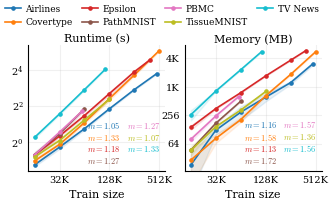

In [40]:

# =============================================================================
# Helpers
# =============================================================================

def dataset_plot_title(name: str) -> str:
    return DATASET_DISPLAY_NAMES.get(name, name)


def safe_parse_dict(x):
    if pd.isna(x):
        return {}
    if isinstance(x, dict):
        return x
    try:
        return ast.literal_eval(x)
    except Exception:
        return {}


def get_results_csv_path(base_dir: Path, ablation_mode: str) -> Path:
    if ablation_mode not in ABLATION_MODE_TO_FOLDER:
        raise ValueError(f"Unknown ABLATION_MODE: {ablation_mode}")
    folder = ABLATION_MODE_TO_FOLDER[ablation_mode]
    filename = ABLATION_MODE_TO_FILENAME[ablation_mode]
    return base_dir / folder / filename


def extract_ablation_value(row, ablation_mode: str):
    if ablation_mode == "dataset":
        return row["dataset"]

    if ablation_mode == "kernel_method":
        return row["kernel_method"]

    if ablation_mode == "model_type":
        return row["model_type"]

    cfg = safe_parse_dict(row.get("ablation_cfg", None))

    if ablation_mode == "max_depth":
        val = cfg.get("max_depth", None)
        return "None" if val is None else str(val)

    if ablation_mode == "min_samples_leaf":
        val = cfg.get("min_samples_leaf", None)
        return "None" if val is None else str(val)

    raise ValueError(f"Unknown ABLATION_MODE: {ablation_mode}")

def add_slope_legend(
    ax,
    slope_items,
    ncol,
    fontsize=6.0,
    loc="best",
):
    """
    Add colored m=... labels as a small legend inside the axes.
    This avoids overlap automatically and lets matplotlib place it.
    """
    if len(slope_items) == 0:
        return None

    handles = [
        Line2D([], [], linestyle="none", linewidth=0, marker=None)
        for _ in slope_items
    ]
    labels = [text for _, text in slope_items]

    leg = ax.legend(
        handles,
        labels,
        loc=loc,
        ncol=ncol,
        frameon=False,
        fontsize=fontsize,
        handlelength=0.0,
        handletextpad=0.0,
        columnspacing=0.8,
        labelspacing=0.2,
        borderaxespad=0.2,
    )

    for txt, (color, _) in zip(leg.get_texts(), slope_items):
        txt.set_color(color)

    return leg


def ablation_value_sort_key(val):
    if val == "None":
        return (1, float("inf"), str(val))
    try:
        return (0, float(val), str(val))
    except Exception:
        return (0, str(val), str(val))


def format_ablation_label(ablation_mode: str, val: str) -> str:
    if ablation_mode == "dataset":
        return dataset_plot_title(val)
    if ablation_mode == "kernel_method":
        return str(val)
    if ablation_mode == "model_type":
        return str(val)
    if ablation_mode == "max_depth":
        return rf"$d={val}$" if val != "None" else r"$d=\mathrm{None}$"
    if ablation_mode == "min_samples_leaf":
        return rf"$n_{{\min}}={val}$" if val != "None" else r"$n_{\min}=\mathrm{None}$"
    return str(val)


def summarize_curve(df: pd.DataFrame, y_col: str, group_col: str) -> pd.DataFrame:
    out = (
        df.groupby([group_col, "n_train_subset"], as_index=False)[y_col]
        .agg(["mean", "std", "count"])
        .reset_index()
    )
    out["sem"] = out["std"] / np.sqrt(out["count"])

    out["lower_se"] = out["mean"] - out["sem"]
    out["upper_se"] = out["mean"] + out["sem"]

    out["lower_std"] = out["mean"] - out["std"]
    out["upper_std"] = out["mean"] + out["std"]

    return out.sort_values([group_col, "n_train_subset"]).reset_index(drop=True)


def fit_log2_slope(x, y, n_tail=None):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    x = x[mask]
    y = y[mask]

    if len(x) < 2:
        return np.nan

    order = np.argsort(x)
    x = x[order]
    y = y[order]

    if n_tail is not None and n_tail > 0 and len(x) > n_tail:
        x = x[-n_tail:]
        y = y[-n_tail:]

    if len(x) < 2:
        return np.nan

    m, _ = np.polyfit(np.log2(x), np.log2(y), 1)
    return float(m)


def pow2_count_formatter(x, pos=None):
    if not np.isfinite(x) or x <= 0:
        return ""

    x_int = int(round(x))

    if x_int >= 2**20:
        val = x_int / 2**20
        return f"{val:.0f}M" if abs(val - round(val)) < 1e-8 else f"{val:.1f}M"
    if x_int >= 2**10:
        val = x_int / 2**10
        return f"{val:.0f}K" if abs(val - round(val)) < 1e-8 else f"{val:.1f}K"
    return f"{x_int}"


def format_mem_tick_binary(x, pos=None):
    if not np.isfinite(x) or x <= 0:
        return ""

    if x >= 1024:
        val = x / 1024
        return f"{val:.0f}K" if abs(val - round(val)) < 1e-8 else f"{val:.1f}K"

    return f"{int(round(x))}" if abs(x - round(x)) < 1e-8 else f"{x:.0f}"


def should_keep_last_point(n_last: int) -> bool:
    if n_last <= 0:
        return True

    if (n_last & (n_last - 1)) == 0:
        return True

    k_floor = int(np.floor(np.log2(n_last)))
    prev_pow = 2 ** k_floor
    next_pow = 2 ** (k_floor + 1)

    dist_prev = n_last - prev_pow
    dist_next = next_pow - n_last

    return dist_next < dist_prev


def truncate_last_endpoint(df: pd.DataFrame, group_cols) -> pd.DataFrame:
    """
    Apply the last-endpoint truncation separately within each group in group_cols.
    """
    df = df.copy()
    keep_mask = np.ones(len(df), dtype=bool)

    for _, g in df.groupby(group_cols):
        sizes = np.sort(g["n_train_subset"].unique())
        if len(sizes) == 0:
            continue

        last_n = int(sizes[-1])
        keep_last = should_keep_last_point(last_n)

        if not keep_last:
            keep_mask[g.index] &= (g["n_train_subset"].to_numpy() != last_n)

    return df.loc[keep_mask].copy()


def prepare_dataframe(df_raw: pd.DataFrame, ablation_mode: str) -> pd.DataFrame:
    df = df_raw.copy()

    df["kernel_pipeline_time_s"] = (
        df["cache_build_time_s"].fillna(0)
        + df["q_build_time_s"].fillna(0)
        + df["full_kernel_time_s"].fillna(0)
    )

    df["kernel_pipeline_peak_mb"] = df[
        ["cache_build_peak_mb", "q_build_peak_mb", "full_kernel_peak_mb"]
    ].fillna(0).max(axis=1)

    if "status" in df.columns:
        df = df[df["status"] == "ok"].copy()

    df["ablation_value"] = df.apply(lambda row: extract_ablation_value(row, ablation_mode), axis=1)

    return df


def choose_ablation_order(values, ablation_mode: str, selected_levels=None):
    values = list(pd.unique(values))

    if selected_levels is not None:
        missing = [v for v in selected_levels if v not in values]
        if missing:
            print(f"Warning: these requested ablation levels are missing: {missing}")
        return [v for v in selected_levels if v in values]

    if ablation_mode in {"max_depth", "min_samples_leaf"}:
        return sorted(values, key=ablation_value_sort_key)

    return values


def make_two_panel_figure(
    df_plot: pd.DataFrame,
    group_values,
    title_text: str,
    save_stem: str,
    legend_labels_map,
):
    if BAND_TYPE not in {"se", "std"}:
        raise ValueError("BAND_TYPE must be either 'se' or 'std'.")

    min_n = 2 ** MIN_POW
    lower_col = f"lower_{BAND_TYPE}"
    upper_col = f"upper_{BAND_TYPE}"

    time_summary = summarize_curve(df_plot, "kernel_pipeline_time_s", "ablation_value")
    mem_summary = summarize_curve(df_plot, "kernel_pipeline_peak_mb", "ablation_value")

    ncols = 2
    left = 0.10
    right = 0.98
    bottom = 0.16
    top_guess = 0.82
    wspace = 0.14
    
    axes_width = FIG_WIDTH * (right - left) / (ncols + (ncols - 1) * wspace)
    fig_height = axes_width / (top_guess - bottom)
    
    fig, axes = plt.subplots(
        1, 2,
        figsize=(FIG_WIDTH, fig_height),
        sharex=True,
        squeeze=False
    )

    ax_runtime = axes[0, 0]
    ax_memory = axes[0, 1]

    ax_runtime.spines["right"].set_visible(False)
    ax_memory.spines["right"].set_visible(False)
    ax_runtime.yaxis.set_ticks_position("left")
    ax_memory.yaxis.set_ticks_position("left")

    colors = plt.cm.tab10(np.linspace(0, 1, len(group_values)))

    legend_handles = []
    legend_labels = []

    runtime_slope_text = []
    memory_slope_text = []

    runtime_band_data = []
    memory_band_data = []

    for color, group_value in zip(colors, group_values):
        dt = (
            time_summary[
                (time_summary["ablation_value"] == group_value)
                & (time_summary["n_train_subset"] >= min_n)
            ]
            .copy()
            .sort_values("n_train_subset")
        )

        dm = (
            mem_summary[
                (mem_summary["ablation_value"] == group_value)
                & (mem_summary["n_train_subset"] >= min_n)
            ]
            .copy()
            .sort_values("n_train_subset")
        )

        if len(dt) < 2 or len(dm) < 2:
            print(f"Skipping {group_value}: not enough points after filtering.")
            continue

        x_t = dt["n_train_subset"].to_numpy()
        y_t = dt["mean"].to_numpy()
        lo_t = dt[lower_col].to_numpy()
        up_t = dt[upper_col].to_numpy()

        x_m = dm["n_train_subset"].to_numpy()
        y_m = dm["mean"].to_numpy()
        lo_m = dm[lower_col].to_numpy()
        up_m = dm[upper_col].to_numpy()

        line_t, = ax_runtime.plot(
            x_t, y_t,
            color=color,
            linestyle="-",
            marker="o",
            markersize=2.3,
            linewidth=1.2,
            zorder=3,
        )

        ax_memory.plot(
            x_m, y_m,
            color=color,
            linestyle="-",
            marker="o",
            markersize=2.3,
            linewidth=1.2,
            zorder=3,
        )

        runtime_band_data.append((x_t, lo_t, up_t, color))
        memory_band_data.append((x_m, lo_m, up_m, color))

        legend_handles.append(line_t)
        legend_labels.append(legend_labels_map[group_value])

        if SHOW_SLOPE_TEXT:
            m_t = fit_log2_slope(x_t, y_t, n_tail=N_TAIL)
            m_m = fit_log2_slope(x_m, y_m, n_tail=N_TAIL)

            runtime_slope_text.append(
                (color, rf"$m={m_t:.2f}$" if np.isfinite(m_t) else r"$m=\mathrm{nan}$")
            )
            memory_slope_text.append(
                (color, rf"$m={m_m:.2f}$" if np.isfinite(m_m) else r"$m=\mathrm{nan}$")
            )

    for ax in [ax_runtime, ax_memory]:
        ax.set_xscale("log", base=2)
        ax.set_yscale("log", base=2)
        ax.grid(True, alpha=0.18, zorder=0)
        ax.tick_params(axis="x", which="both", length=0, colors="black")
        ax.tick_params(axis="y", which="both", length=0, colors="black")
        ax.xaxis.set_major_formatter(FuncFormatter(pow2_count_formatter))

    ax_runtime.relim()
    ax_runtime.autoscale_view()
    runtime_xlim = ax_runtime.get_xlim()
    runtime_ylim = ax_runtime.get_ylim()

    ax_memory.relim()
    ax_memory.autoscale_view()
    memory_xlim = ax_memory.get_xlim()
    memory_ylim = ax_memory.get_ylim()

    if PLOT_ERROR_BANDS:
        for x_t, lo_t, up_t, color in runtime_band_data:
            ax_runtime.fill_between(x_t, lo_t, up_t, color=color, alpha=0.10, zorder=1)

        for x_m, lo_m, up_m, color in memory_band_data:
            ax_memory.fill_between(x_m, lo_m, up_m, color=color, alpha=0.10, zorder=1)

        ax_runtime.set_xlim(runtime_xlim)
        ax_runtime.set_ylim(runtime_ylim)
        ax_memory.set_xlim(memory_xlim)
        ax_memory.set_ylim(memory_ylim)

    ax_runtime.set_title("Runtime (s)", pad=2)
    ax_memory.set_title("Memory (MB)", pad=2)

    ax_runtime.set_ylabel("")
    ax_memory.set_ylabel("")

    ax_runtime.set_xlabel("Train size")
    ax_memory.set_xlabel("Train size")

    ax_memory.yaxis.set_major_formatter(FuncFormatter(format_mem_tick_binary))

    if SHOW_SLOPE_TEXT:
        add_slope_legend(
            ax_runtime,
            runtime_slope_text,
            ncol=N_COL_SLOPE_LEG,
            fontsize=6.0,
            loc="best",
        )
    
        add_slope_legend(
            ax_memory,
            memory_slope_text,
            ncol=N_COL_SLOPE_LEG,
            fontsize=6.0,
            loc="best",
        )

    top_legend = fig.legend(
        legend_handles,
        legend_labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.0),
        ncol=N_COL_LEG,
        frameon=False,
        handlelength=1.8,
        columnspacing=1.0,
        handletextpad=0.5,
    )
    
    fig.canvas.draw()
    legend_bbox_fig = top_legend.get_window_extent(
        renderer=fig.canvas.get_renderer()
    ).transformed(fig.transFigure.inverted())
    
    legend_bottom = legend_bbox_fig.y0
    top = legend_bottom - LEG_SPACE_TOP
    
    fig.subplots_adjust(left=left, right=right, bottom=bottom, top=top, wspace=wspace)

    suffix_parts = [
        ABLATION_MODE,
        "sidebyside",
        f"kgeq{MIN_POW}",
        f"bands-{BAND_TYPE}" if PLOT_ERROR_BANDS else "nobands",
        f"slopes-tail{N_TAIL}" if SHOW_SLOPE_TEXT else "noslopes",
        f"ncolleg-{N_COL_LEG}",
    ]
    out_base = FIG_DIR / f"{save_stem}_{'_'.join(suffix_parts)}"

    fig.savefig(out_base.with_suffix(".pdf"))
    fig.savefig(out_base.with_suffix(".png"), dpi=300)
    plt.show()


# =============================================================================
# Load and prepare data
# =============================================================================

csv_path = get_results_csv_path(BASE_RESULTS_DIR, ABLATION_MODE)
print(f"Loading CSV from: {csv_path}")

df_raw = pd.read_csv(csv_path)
df_plot = prepare_dataframe(df_raw, ABLATION_MODE)

if ABLATION_MODE == "dataset":
    group_cols_for_truncation = ["dataset"]
else:
    group_cols_for_truncation = ["dataset", "ablation_value"]

df_plot = truncate_last_endpoint(df_plot, group_cols_for_truncation)

print(f"ABLATION_MODE: {ABLATION_MODE}")
print(f"Rows after filtering/truncation: {len(df_plot)}")


# =============================================================================
# Dataset ablation: one global figure, curves = datasets
# =============================================================================

if ABLATION_MODE == "dataset":
    available_datasets = list(pd.unique(df_plot["dataset"]))
    missing = [ds for ds in SELECTED_DATASETS if ds not in available_datasets]
    if missing:
        raise ValueError(f"These selected datasets are missing from df_plot: {missing}")

    df_use = df_plot[df_plot["dataset"].isin(SELECTED_DATASETS)].copy()
    df_use["ablation_value"] = df_use["dataset"]

    group_values = [ds for ds in SELECTED_DATASETS if ds in set(df_use["ablation_value"])]
    legend_labels_map = {ds: dataset_plot_title(ds) for ds in group_values}

    print("Datasets to plot:", group_values)
    print(f"Plot error bands: {PLOT_ERROR_BANDS}")
    print(f"Band type: {BAND_TYPE}")
    print(f"Show slope text: {SHOW_SLOPE_TEXT}")
    print(f"N_TAIL: {N_TAIL}")
    print(f"N_COL_LEG: {N_COL_LEG}")

    print("\nRemaining train sizes by dataset:")
    for ds in group_values:
        sizes = sorted(df_use.loc[df_use["ablation_value"] == ds, "n_train_subset"].unique())
        print(ds, sizes)

    make_two_panel_figure(
        df_plot=df_use,
        group_values=group_values,
        title_text="Dataset ablation",
        save_stem="dataset_ablation_two_panel_single_column",
        legend_labels_map=legend_labels_map,
    )


# =============================================================================
# Other ablations: one figure per dataset, curves = ablation levels
# =============================================================================

else:
    available_datasets = list(pd.unique(df_plot["dataset"]))
    missing = [ds for ds in SELECTED_DATASETS_OTHER_ABLATIONS if ds not in available_datasets]
    if missing:
        raise ValueError(f"These selected datasets are missing from df_plot: {missing}")

    print("Datasets to plot:", SELECTED_DATASETS_OTHER_ABLATIONS)
    print(f"Plot error bands: {PLOT_ERROR_BANDS}")
    print(f"Band type: {BAND_TYPE}")
    print(f"Show slope text: {SHOW_SLOPE_TEXT}")
    print(f"N_TAIL: {N_TAIL}")
    print(f"N_COL_LEG: {N_COL_LEG}")

    for dataset_name in SELECTED_DATASETS_OTHER_ABLATIONS:
        df_ds = df_plot[df_plot["dataset"] == dataset_name].copy()

        available_levels = list(pd.unique(df_ds["ablation_value"]))
        group_values = choose_ablation_order(
            available_levels,
            ablation_mode=ABLATION_MODE,
            selected_levels=SELECTED_ABLATION_LEVELS,
        )

        df_ds = df_ds[df_ds["ablation_value"].isin(group_values)].copy()

        legend_labels_map = {
            val: format_ablation_label(ABLATION_MODE, val)
            for val in group_values
        }

        print(f"\nDataset: {dataset_name}")
        print("Ablation levels:", group_values)

        for val in group_values:
            sizes = sorted(df_ds.loc[df_ds["ablation_value"] == val, "n_train_subset"].unique())
            print(f"  {val}: {sizes}")

        make_two_panel_figure(
            df_plot=df_ds,
            group_values=group_values,
            title_text=f"{ABLATION_MODE.replace('_', ' ')} ablation",
            save_stem=f"{ABLATION_MODE}_{dataset_name}_two_panel_single_column",
            legend_labels_map=legend_labels_map,
        )